In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pickle
import gzip

from qiskit.quantum_info import SparsePauliOp

from matplotlib import pyplot as plt

from qphaset.phases import phases_vfield, gstates_to_rdms_matrix_qs_mps
from qphaset.plotting import plot_grad_g_angle_stream
from qphaset.linalg import schmidt_decomp_half, schmidt_decomp_2q_angles

In [2]:
gamma = None

## General solution (beta) for the order parameter discovery.
This is the (beta!) implementation of the most general form of the order parameter discovery (in the paper, this is the second problem in the section deicated to the order parameter discovery, soon more details will be expanded).

In [62]:
model_name = "Cluster"
l = 12
n = 20
params = np.linspace(0.1, 1.5, n), np.linspace(1.5, 0.1, n) # upside-down

model_name = "ANNNI"
l = 12
n = 30
params = np.linspace(0.5, 2.1, n), np.linspace(1.6, 0.01, n) # upside-down

params = map(lambda m: m.flatten(), np.meshgrid(*params, indexing='xy'))
params = tuple(params)
params = np.stack(params).T
params_extent = np.concatenate([np.min(params, axis=0), np.max(params, axis=0)])
params_extent = tuple(params_extent[[0, 2, 1, 3]])

theta = 0
#gamma = 50
obs_ev_idx = 2
v0_first_schmidt_vec = False

device = 'pc'
# device = 'ngt'

if device == 'pc':
    device_path = "D:/code"
elif device == 'ngt':
    device_path = "/eos/user/f/fdimarca"

# dmrg params
chi = 100 # bond dimension
c1 = 1e-3 # eps symm. break.
if model_name == 'ANNNI':
    path_to_tensor = f"{device_path}/projects/2_ANNNI/results/data"
    path_to_figures = f"{device_path}/projects/2_ANNNI/figures"
    axis_name = ('k', 'h')

elif model_name == 'Cluster':
    path_to_tensor = f"{device_path}/projects/3_CLUSTER/results/data"
    path_to_figures = f"{device_path}/projects/3_CLUSTER/figures"
    axis_name = ('k', 'h')

elif model_name == 'Rydberg':
    path_to_tensor = f"{device_path}/projects/4_RYDBERG/results/data"
    path_to_figures = f"{device_path}/projects/4_RYDBERG/figures"
    axis_name = ('$\\Delta/\\Omega$', '$R_b/a$')

else:
    raise SyntaxError("Choose a valid model among 'ANNNI', 'Cluster', and 'Rydberg'")


filename = f'{path_to_tensor}/{model_name}_L_{l}_lambda_1_{params_extent[2]}-{params_extent[3]}_lambda_2_{params_extent[0]}-{params_extent[1]}_npoints_{n}x{n}_chi_{chi}_eps_{c1}.pkl'
# filename = f'{path_to_tensor}/{model_name}_L_{l}_lambda_1_{params_extent[2]}-{params_extent[3]}_lambda_2_{params_extent[0]}-{params_extent[1]}_npoints_{n}x{n}.pkl'


with gzip.open(filename, 'rb') as f:
    data = pickle.load(f)
params = data['params']
l, n = data['l'], data['n']
gstates = data['gstates']
stats = data['stats']

params_extent = np.concatenate([np.min(params, axis=0), np.max(params, axis=0)])
params_extent = tuple(params_extent[[0, 2, 1, 3]])

def sanitize_state(state):
    # ensure flat list of arrays
    return [np.array(t) for t in state]

gstates = [
    sanitize_state(state)
    for row in gstates
    for state in (row if isinstance(row, (list, np.ndarray)) else [row])
]
sites = [l // 2]
#sites = [2]
sites = [l // 2, l // 2 + 1]
sites = [l // 2 - 1, l // 2, l // 2 + 1]

rdms = gstates_to_rdms_matrix_qs_mps(gstates, sites=sites, generalized=True)

rdm comp: 900: 100%|██████████| 900/900 [00:16<00:00, 55.44it/s]


In [67]:
# uncomment if you wanna select a sub matrix of params
select_sub_mat = True

if select_sub_mat:
    x0, y0 = 1, 1

    # Parameter axes
    x_vals = np.linspace(0.5, 2.1, n)
    y_vals = np.linspace(1.6, 0.01, n)

    # Example matrix
    M = np.random.rand(n, n)

    def extract_submatrix(matrix, x_vals, y_vals,
                        x0, y0,
                        dx=2, dy=2, to_end=True):
        """
        Extract submatrix centered around parameter point (x0, y0).

        Parameters
        ----------
        matrix : 2D array
        x_vals : 1D x-axis values
        y_vals : 1D y-axis values
        x0, y0 : target parameter values
        dx, dy : half-width in index space

        Returns
        -------
        submatrix, x_indices, y_indices
        """

        # Closest grid indices
        ix = np.argmin(np.abs(x_vals - x0))
        iy = np.argmin(np.abs(y_vals - y0))

        # Bounds
        if to_end:
            x_start = ix - dx
            x_end   = len(x_vals) - 1

            y_start = iy - dy
            y_end   = len(y_vals) - 1
        else:
            x_start = 0
            x_end = ix + dx

            y_start = 0
            y_end = iy + dy

        if x_end - x_start != y_end - y_start:
            min_len = min(x_end - x_start, y_end - y_start)
            if x_end - x_start > min_len:
                if to_end:
                    x_end = x_start + min_len
                else:
                    x_start = x_end - min_len
            elif y_end - y_start > min_len:
                if to_end:
                    y_end = y_start + min_len
                else:
                    y_start = y_end - min_len
                
        submatrix = matrix[y_start:y_end, x_start:x_end].copy()

        return submatrix, tuple([x_start, x_end, y_start, y_end])

    rdms_red, params_extent_red_idx = extract_submatrix(rdms, x_vals, y_vals, x0, y0, dx=1, dy=1)
    params_extent_red = np.array([x_vals[i] for i in params_extent_red_idx[:2]] + [y_vals[i] for i in params_extent_red_idx[2:]])
    params_extent_red = tuple(params_extent_red[[0,1,3,2]])
    print(rdms.shape)
    print(rdms_red.shape)
    print(params_extent_red)
    print(params_extent_red_idx)

(30, 30, 8, 8)
(19, 19, 8, 8)
(np.float64(0.9413793103448276), np.float64(1.9896551724137932), np.float64(0.01), np.float64(1.0517241379310347))
(np.int64(8), np.int64(27), np.int64(10), 29)


In [5]:
# theta = 0  # Adjust st phases have opposite signs.
# Most of the times theta=0 is good, however, use theta=pi to obtain the complementary
# order parameter. 

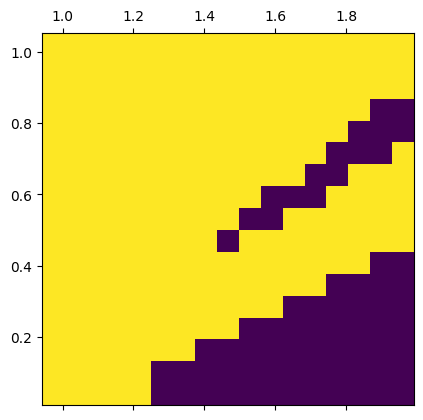

In [96]:
grad_g = phases_vfield(rdms_red, scale=1)
ys = np.sin(np.angle(grad_g) + theta)

# Labels plot
plt.matshow(np.sign(ys), origin='lower', extent=params_extent_red, aspect='auto');

In [69]:
rdms = rdms[1:-1, 1:-1] # TODO fix

In [70]:
lattice_shape = rdms.shape[:2]
rdms = np.reshape(rdms, (-1, ) + rdms.shape[2:])
ys = ys.flatten()

In [71]:
# define the observable
rhoa = rdms[np.nonzero(ys > 0)]
rhob = rdms[np.nonzero(ys < 0)]
rhoa = np.average(rhoa, axis=0)
rhob = np.average(rhob, axis=0)

rhoa = rhoa / np.linalg.norm(rhoa)
rhob = rhob / np.linalg.norm(rhob)

dot_ab = np.trace(rhoa * rhob)
obs = rhoa - dot_ab * rhob
obs = obs / np.sqrt(1 - dot_ab ** 2)

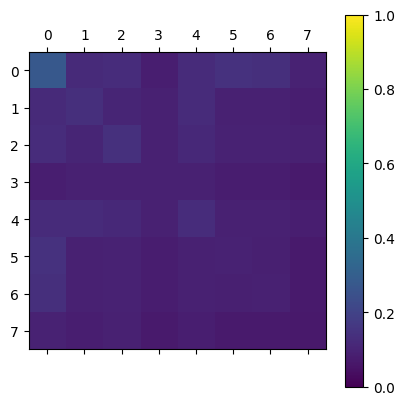

In [95]:
plt.matshow(np.abs(obs), vmin=0, vmax=1)
plt.colorbar();

In [73]:
obs_eval, obs_ev = np.linalg.eigh(obs)
# Eigenvalues of the observable, check here the magnitudes (check also the sign!) and explore the specific projectors
# by setting the variable obs_ev_idx with the index of the selected eigenvector.
obs_eval

array([2.10054242e-04, 8.30298641e-04, 2.86342381e-03, 5.04576736e-03,
       2.21760706e-02, 3.76474053e-02, 1.17540477e-01, 8.37092123e-01])

In [74]:
SparsePauliOp.from_operator(obs)

SparsePauliOp(['III', 'IIX', 'IIZ', 'IXI', 'IXX', 'IXZ', 'IYY', 'IZI', 'IZX', 'IZZ', 'XII', 'XIX', 'XIZ', 'XXI', 'XXX', 'XXZ', 'XYY', 'XZI', 'XZX', 'XZZ', 'YIY', 'YXY', 'YYI', 'YYX', 'YYZ', 'YZY', 'ZII', 'ZIX', 'ZIZ', 'ZXI', 'ZXX', 'ZXZ', 'ZYY', 'ZZI', 'ZZX', 'ZZZ'],
              coeffs=[ 0.1279257 -1.54388105e-20j, -0.09427025+1.52067843e-20j,
  0.03023058-5.46096704e-22j,  0.09717232-1.34750433e-20j,
 -0.09075081+1.33920497e-20j,  0.0137933 -5.06963938e-22j,
 -0.00536611-5.76628791e-24j,  0.03022786-4.68599344e-21j,
 -0.01249587+4.63342236e-21j,  0.01248927-1.04160382e-22j,
  0.09523295-1.19133764e-20j, -0.1101661 +1.20325362e-20j,
  0.01310516-5.04446085e-22j,  0.10334871-6.35910350e-21j,
 -0.09415122+6.32607710e-21j,  0.02116961-4.12707338e-22j,
 -0.00021277+1.47819237e-24j,  0.01238777-1.51387179e-21j,
 -0.02369686+1.57619117e-21j,  0.00161123-3.97844504e-23j,
  0.0073453 -4.14297790e-23j,  0.00153063-3.81163723e-23j,
 -0.00703074+9.87612241e-21j,  0.0005845 -9.86095807e-21j,
 -0

In [75]:
# TODO Sanity-check. Check that candidate observables not numerically close to Hermitian
# correspond to eigenvalues numerically close to 0.

In [76]:
# TODO Sanity-check on the presence of positive and negative eigenvalues not numerically close to 0.
# Note these are not the eigenvalues of the observable.

In [77]:
# get the most relevant Pauli components of the observable 
operators = SparsePauliOp.from_operator(obs)
sorted_indices = np.argsort(operators.coeffs)[::-1]
components = operators.paulis
sorted_components = [components[i] for i in sorted_indices]

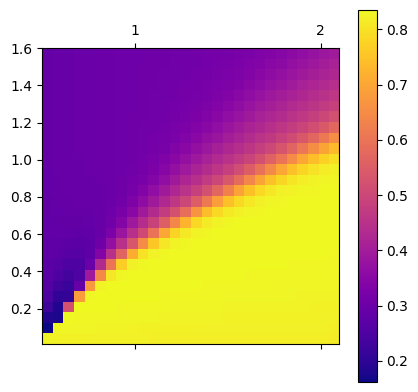

In [94]:
meas = [np.trace(rdm @ obs) for rdm in rdms]
meas = np.reshape(meas, lattice_shape)

# Note we plot the **absolute value**. The ordered phase can assume any non-zero value (positive and negative).
# So, we identify the disordered phase with the values close to 0 (numerically).
plt.matshow(np.abs(meas), origin='lower', cmap='plasma', extent=params_extent)
plt.colorbar();

### Analysis of a selected eigenvector of the observable

Key parameters: `obs_ev_idx` (eigenvector index) and `v0_first_schmidt_vec`.

In [79]:
# Select a rank-1 observable (note the ordering of the eigenvalues of obs).
obs_ev_idx = 2

v0 = obs_ev[:, obs_ev_idx]

# Schmidt coefficients w.r.t. middle split
v0_schmidt_coeffs = schmidt_decomp_half(v0)[1]
v0_schmidt_coeffs

array([0.99225279, 0.12423523])

In [80]:
# Angles for each qubit in the decomposition of v0 (assumed 2 qubits state).
if len(sites) == 2:
    schmidt_decomp_2q_angles(v0)[0], schmidt_decomp_2q_angles(v0)[0] / np.pi

In [81]:
# Optionally take first component of Schmidt decomp.
# v0_first_schmidt_vec = True

if v0_first_schmidt_vec:
    v0 = schmidt_decomp_half(v0, contract_sigmas=1, normalize=True)

v0 = np.reshape(v0, (-1, 1))
obs0 = np.sign(obs_eval[obs_ev_idx]) * v0 @ np.conj(v0.T)

SparsePauliOp.from_operator(obs0)

SparsePauliOp(['III', 'IIX', 'IIZ', 'IXI', 'IXX', 'IXZ', 'IYY', 'IZI', 'IZX', 'IZZ', 'XII', 'XIX', 'XIZ', 'XXI', 'XXX', 'XXZ', 'XYY', 'XZI', 'XZX', 'XZZ', 'YIY', 'YXY', 'YYI', 'YYX', 'YYZ', 'YZY', 'ZII', 'ZIX', 'ZIZ', 'ZXI', 'ZXX', 'ZXZ', 'ZYY', 'ZZI', 'ZZX', 'ZZZ'],
              coeffs=[ 0.125     +0.j, -0.03559873+0.j, -0.02920406+0.j, -0.02840061+0.j,
  0.11635762+0.j, -0.0090558 +0.j,  0.11355446-0.j,  0.03479364+0.j,
 -0.01996597+0.j, -0.11799907+0.j, -0.01295105+0.j,  0.0172269 +0.j,
  0.02169008+0.j,  0.00981808+0.j, -0.00459183+0.j,  0.01289022+0.j,
 -0.00327761+0.j, -0.02781701+0.j,  0.02259584+0.j,  0.00753306+0.j,
 -0.01538074+0.j, -0.02130204+0.j, -0.01842612+0.j,  0.02445035-0.j,
 -0.01074123+0.j, -0.01250847+0.j, -0.12044712+0.j,  0.03135159+0.j,
  0.02961895+0.j,  0.03113867+0.j, -0.1191467 +0.j,  0.01055127+0.j,
 -0.11514141+0.j, -0.03152052+0.j,  0.01639139+0.j,  0.11732519+0.j])

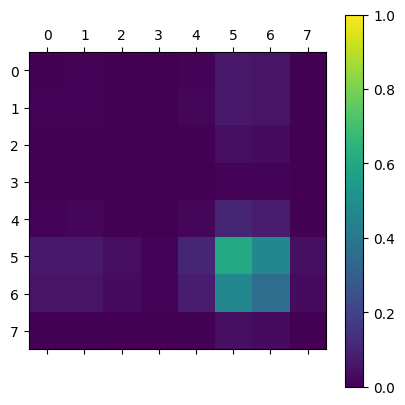

In [93]:
plt.matshow(np.abs(obs0), vmin=0, vmax=1) # better abs or real?
plt.colorbar();

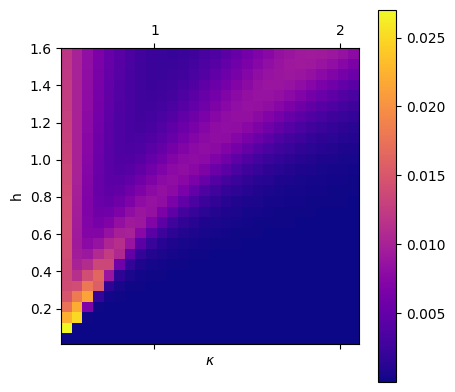

In [92]:
meas = [np.trace(rdm @ obs0) for rdm in rdms]
meas = np.reshape(meas, lattice_shape)

# Note we plot the absolute value to avoid misunderstanding in the interpretation of the
# colormap.
plt.matshow(np.abs(meas), origin='lower', cmap='plasma', extent=params_extent)
plt.xlabel('$\\kappa$')
plt.ylabel('h')
plt.colorbar();

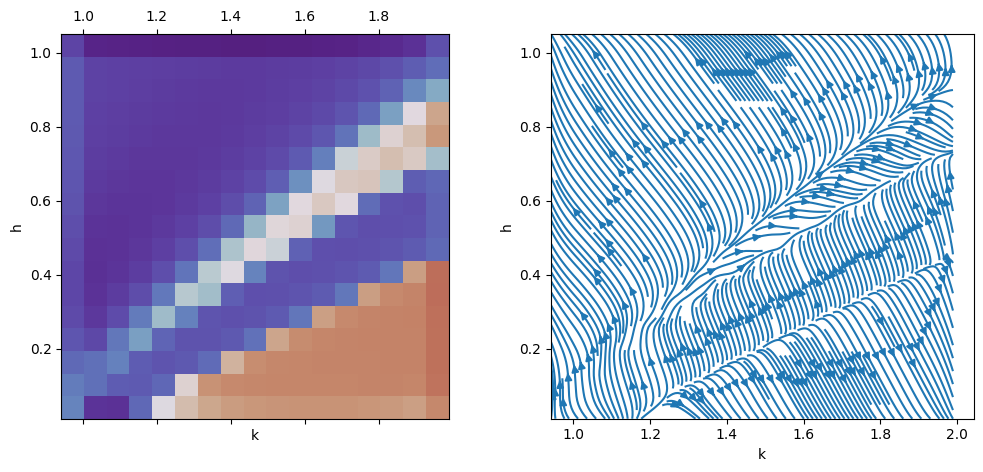

In [84]:
plot_grad_g_angle_stream(grad_g, params_extent=params_extent_red, theory_lines=False);

### Plot all the schmidt vector observables

In [89]:
def make_obs_vec(obs_ev, obs_ev_idx):
    v0 = obs_ev[:, obs_ev_idx]

    # Schmidt coefficients w.r.t. middle split
    if v0_first_schmidt_vec:
        v0 = schmidt_decomp_half(v0, contract_sigmas=1, normalize=True)

    v0 = np.reshape(v0, (-1, 1))
    obs0 = np.sign(obs_eval[obs_ev_idx]) * v0 @ np.conj(v0.T)
    return obs0

def get_obs_ev(obs):
    obs_eval, obs_ev = np.linalg.eigh(obs)
    return obs_ev

def decompose_obs(obs, k_sites=2):
    operators = SparsePauliOp.from_operator(obs)
    sorted_indices = np.argsort(operators.coeffs)[::-1]
    components = operators.paulis
    sorted_components = [components[i] for i in sorted_indices]
    return sorted_components[:2**(k_sites)]

def plot_observable(obs, sites=None, component=None):
    meas = [np.trace(rdm @ obs) for rdm in rdms]
    meas = np.reshape(meas, lattice_shape)

    # Note we plot the absolute value to avoid misunderstanding in the interpretation of the
    # colormap.
    fig, ax = plt.subplots(1,2, figsize=(10,4.5))
    ax0 = ax[0].matshow(np.abs(meas), origin='lower', cmap='plasma', aspect='auto', extent=params_extent)
    fig.colorbar(ax0, ax=ax[0])
    ax[0].set_xlabel('$\\kappa$')
    ax[0].set_ylabel('h')
    if component is None:
        title_str = "Whole Observable"
        figure_name = f"{path_to_figures}/{model_name}_L_{l}_{n}x{n}_{len(sites)}-rdm_OPD.png"
    else:
        title_str = f"Eigvec: {component}"
        figure_name = f"{path_to_figures}/{model_name}_L_{l}_{n}x{n}_{len(sites)}-rdm_OPD_component_{component}.png"
    ax[0].set_title(title_str)

    sorted_components = decompose_obs(obs, len(sites))
    # ax1 = ax[1].matshow(obs.real, aspect='auto')
    ax1 = ax[1].matshow(np.abs(obs), aspect='auto', vmin=0, vmax=1)
    fig.colorbar(ax1, ax=ax[1])
    ax[1].set_xticks(range(len(sorted_components)), sorted_components)
    ax[1].set_yticks(range(len(sorted_components)), sorted_components)
    ax[1].set_title("Pauli Decomposition")
    plt.tight_layout()

    plt.savefig(figure_name)
    plt.show()

def plot_k_components(obs, sites):
    obs_ev = get_obs_ev(obs)
    for obs_ev_idx in range(2**len(sites)):
        obs_vec = make_obs_vec(obs_ev, obs_ev_idx)
        plot_observable(obs_vec, sites, component=obs_ev_idx)

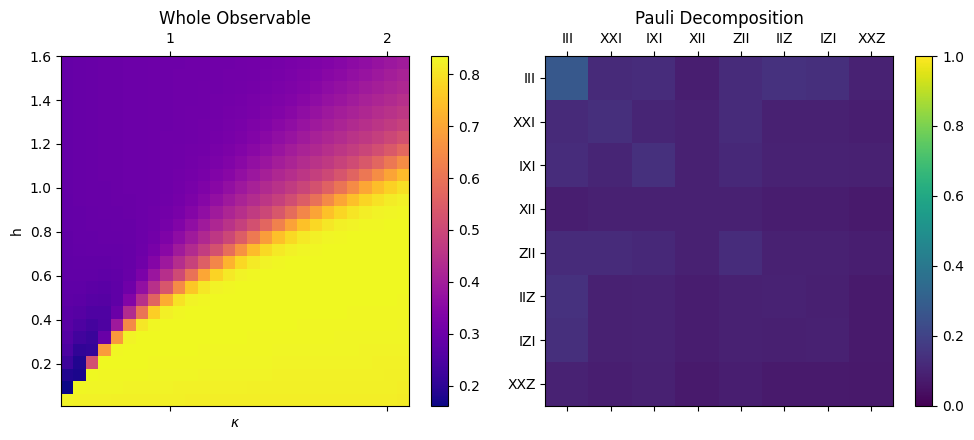

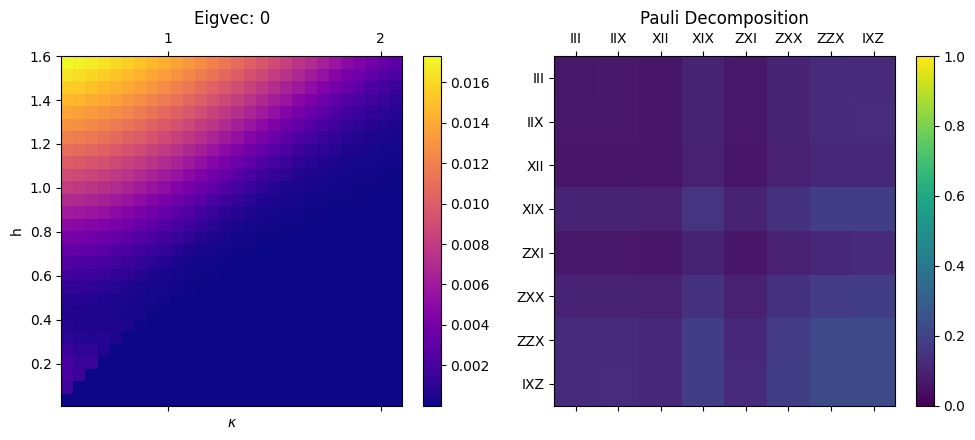

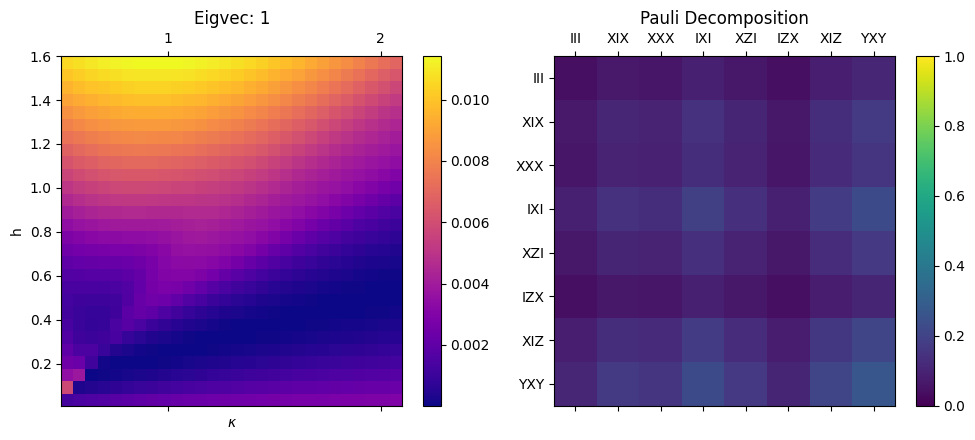

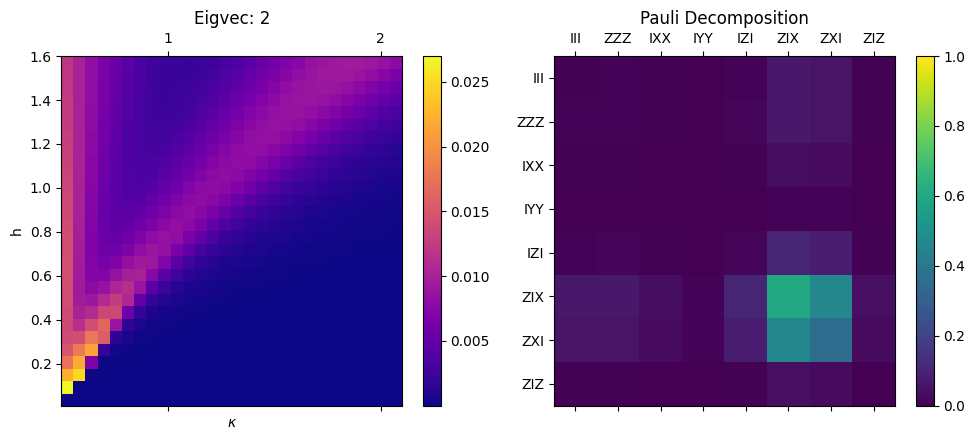

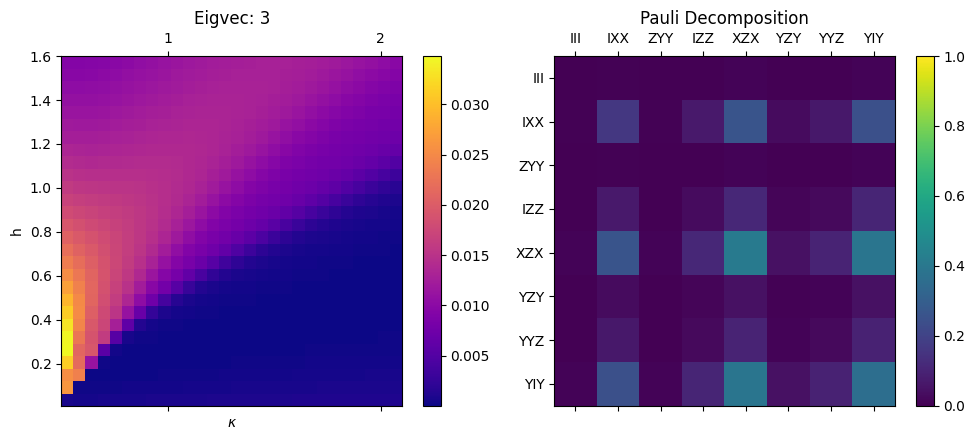

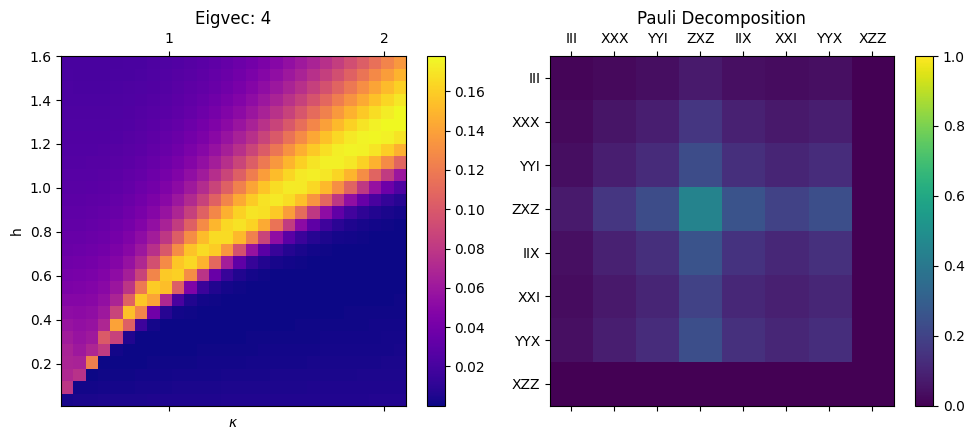

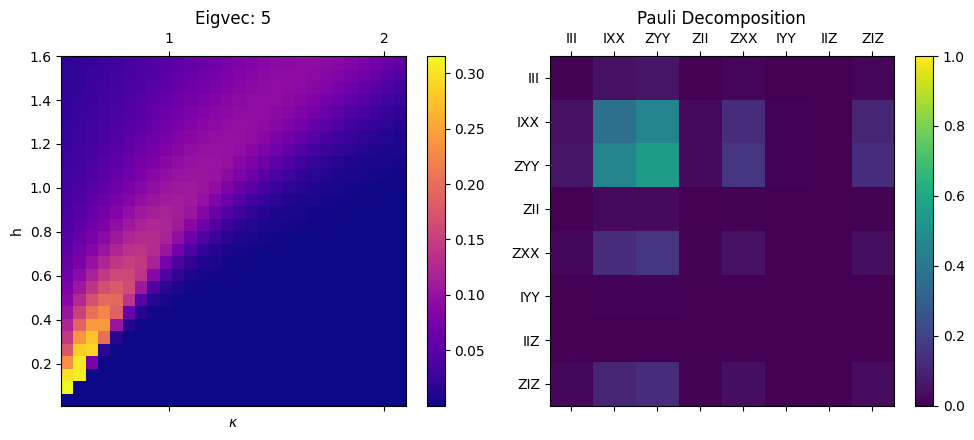

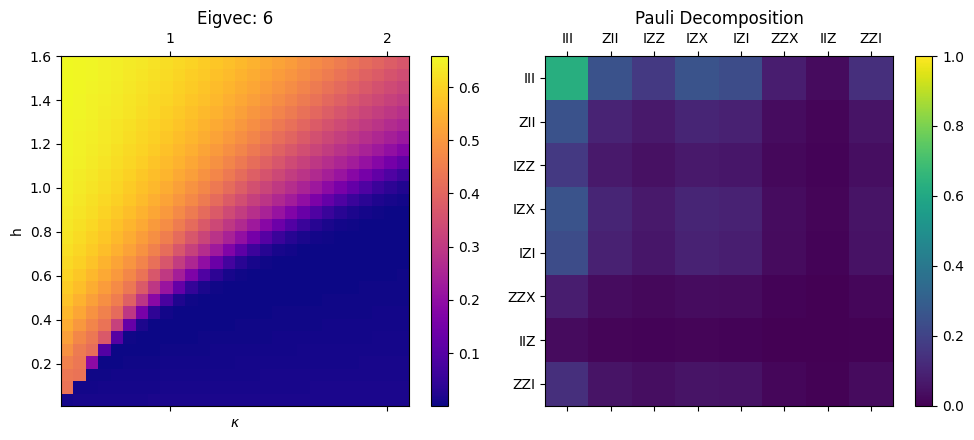

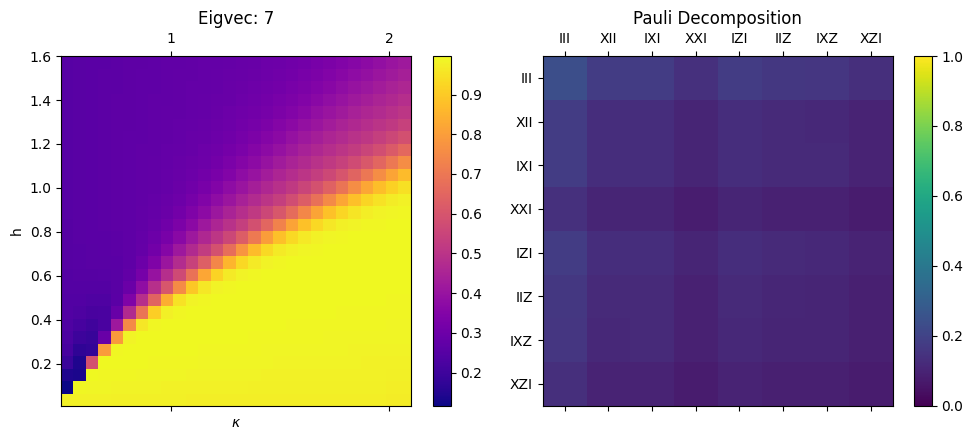

(None, None)

In [90]:
plot_observable(obs, sites), plot_k_components(obs, sites)